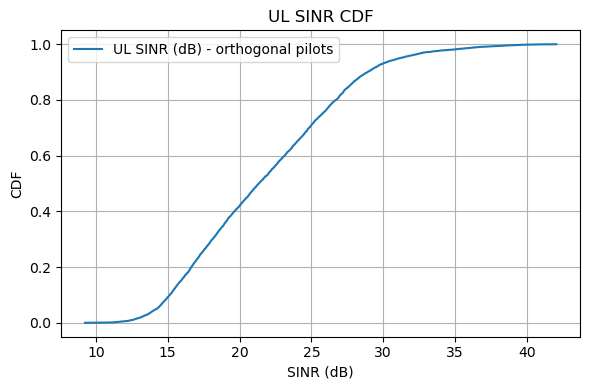

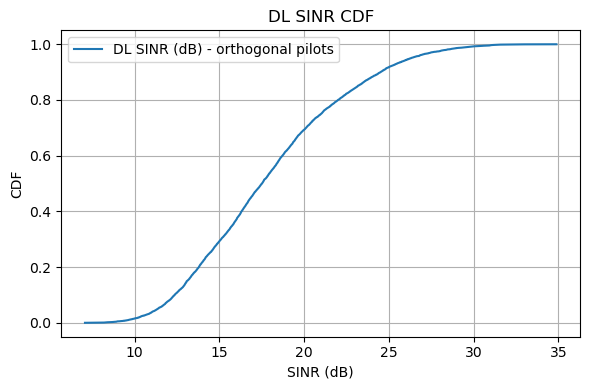

=== UL SINR (dB) with ORTHOGONAL pilots ===
p5=14.23, p50=21.33, p95=31.14
=== DL SINR (dB) with ORTHOGONAL pilots ===
p5=11.35, p50=17.51, p95=26.30


In [1]:
# ============================================================
# UC CF-mMIMO with Reduced Pilot Contamination (Orthogonal pilots)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, solve
rng = np.random.default_rng(7)

# -------------------- System parameters --------------------
L, K, N = 100, 35, 4
AREA, AP_HEIGHT, UE_HEIGHT = 1000.0, 10.0, 1.5

# Noise
BW, NF_dB, N0_dBm_perHz = 20e6, 7.0, -174.0
noise_power_dBm = N0_dBm_perHz + 10*np.log10(BW) + NF_dB
sigma2 = 10**(noise_power_dBm/10)/1000.0

# Powers
P_UL_user, P_pilot, P_DL_AP_max = 0.1, 0.1, 0.2

# Coherence block
tau_c, tau_u = 200, 95
tau_p_ortho = K
tau_d = tau_c - tau_p_ortho - tau_u
assert tau_d > 0, "Increase tau_c or reduce tau_u for orthogonal pilots."

# Cluster
CLUSTER_SIZE, rho_corr = 10, 0.7

# Pathloss
PL_intercept_dB, PL_exponent, shadow_sigma_dB = -30.5, 36.7, 3.0

# Simulation realizations
NUM_REALIZATIONS = 200

# -------------------- Helpers --------------------
def toeplitz_exp(rho, N):
    idx = np.arange(N)
    return rho ** np.abs(np.subtract.outer(idx, idx))

def gen_positions(L, K, area):
    ap_xy = rng.uniform(0, area, size=(L, 2))
    ue_xy = rng.uniform(0, area, size=(K, 2))
    return ap_xy, ue_xy

def lsfc_matrix(ap_xy, ue_xy):
    d2d = np.linalg.norm(ap_xy[:, None, :] - ue_xy[None, :, :], axis=-1)
    d3d = np.sqrt(d2d**2 + (AP_HEIGHT-UE_HEIGHT)**2)
    F = rng.normal(0.0, shadow_sigma_dB, size=(L, K))
    beta_dB = PL_intercept_dB - PL_exponent * np.log10(d3d) + F
    return 10**(beta_dB/10.0)

def assign_pilots_orthogonal(K):
    return np.arange(K)

def sample_channel(Rcorr, beta_lk):
    chol = np.linalg.cholesky(Rcorr)
    Z = (rng.standard_normal((L, K, N)) + 1j*rng.standard_normal((L, K, N)))/np.sqrt(2.0)
    h = Z @ chol.T
    h *= np.sqrt(beta_lk[..., None])
    return h

def lp_mmse_estimation(h, Rcorr, beta_lk, pilots, P_pilot, tau_p):
    I = np.eye(N, dtype=np.complex128)
    groups = [np.where(pilots == t)[0] for t in range(tau_p)]
    hhat = np.zeros_like(h, dtype=np.complex128)
    Cerr_trace = np.zeros((L, K), dtype=np.float64)
    sqrt_pt = np.sqrt(P_pilot * tau_p)
    for l in range(L):
        for idxs in groups:
            if len(idxs) == 0:
                continue
            y_lt = sqrt_pt * np.sum(h[l, idxs, :], axis=0)
            n = np.sqrt(sigma2/2)*(rng.standard_normal(N) + 1j*rng.standard_normal(N))
            y_lt = y_lt + n
            S = (P_pilot * tau_p) * (np.sum(beta_lk[l, idxs]) * Rcorr) + sigma2 * I
            S_inv = inv(S)
            for k in idxs:
                R_kl = beta_lk[l, k] * Rcorr
                hhat[l, k, :] = sqrt_pt * (R_kl @ (S_inv @ y_lt))
                C = R_kl - (P_pilot * tau_p) * (R_kl @ (S_inv @ R_kl))
                Cerr_trace[l, k] = float(np.real(np.trace(C)))
    return hhat, Cerr_trace

def local_lpmmse_combiner(hhat, Cerr_trace, rho_ul_users):
    I = np.eye(N, dtype=np.complex128)
    v = np.zeros_like(hhat, dtype=np.complex128)
    for l in range(L):
        G = np.zeros((N, N), dtype=np.complex128)
        trC = 0.0
        for i in range(K):
            hh = hhat[l, i, :][:, None]
            G += rho_ul_users[i] * (hh @ hh.conj().T)
            trC += rho_ul_users[i] * Cerr_trace[l, i]
        A_inv = inv(G + (trC/N + sigma2) * I)
        v[l, :, :] = (A_inv @ hhat[l, :, :].T).T
    return v

def form_user_clusters(beta_lk, cluster_size):
    M_k = []
    for k in range(K):
        top = np.argsort(beta_lk[:, k])[-cluster_size:]
        M_k.append(np.sort(top))
    D_l = [set() for _ in range(L)]
    for k in range(K):
        for l in M_k[k]:
            D_l[l].add(k)
    D_l = [sorted(list(s)) for s in D_l]
    return M_k, D_l

def ul_sinr(h, v, M_k, rho_ul_users):
    sinr = np.zeros(K)
    for k in range(K):
        cluster = M_k[k]
        gk = np.zeros((len(cluster),), dtype=np.complex128)
        G = np.zeros((len(cluster), K), dtype=np.complex128)
        vnorm = np.zeros((len(cluster),), dtype=np.float64)
        for idx, l in enumerate(cluster):
            vkl = v[l, k, :]
            vnorm[idx] = float(np.real(np.vdot(vkl, vkl)))
            G[idx, :] = vkl.conj().T @ h[l, :, :].T
            gk[idx] = G[idx, k]
        R_i = (G * rho_ul_users).dot(G.conj().T) + sigma2 * np.diag(vnorm)
        try: alpha = solve(R_i, gk)
        except np.linalg.LinAlgError: alpha = np.linalg.pinv(R_i) @ gk
        num = rho_ul_users[k] * np.abs(alpha.conj().T @ gk)**2
        den = (alpha.conj().T @ (R_i - rho_ul_users[k] * np.outer(gk, gk.conj())) @ alpha).real
        sinr[k] = float((num/den).real) if den > 0 else 0.0
    return sinr

def dl_sinr(h, v, M_k, D_l, P_DL_AP_max, rho_ul_users):
    norms = np.linalg.norm(v, axis=2) + 1e-12
    f = v / norms[:, :, None]
    sinr = np.zeros(K)
    for k in range(K):
        desired, interf = 0+0j, 0.0
        for i in range(K):
            ls = [l for l in range(L) if i in D_l[l]]
            if not ls: continue
            Hl = h[ls, k, :]
            fl = f[ls, i, :]
            eff = np.sum(np.sum(Hl.conj() * fl, axis=1))
            if i == k: desired = eff
            else: interf += np.abs(eff)**2
        sinr[k] = float((np.abs(desired)**2 / (interf + sigma2)).real)
    return sinr

def ecdf(x):
    xs = np.sort(x); ys = np.linspace(0, 1, len(xs), endpoint=False); return xs, ys

# -------------------- Simulation --------------------
ap_xy, ue_xy = gen_positions(L, K, AREA)
beta_lk = lsfc_matrix(ap_xy, ue_xy)
Rcorr = toeplitz_exp(rho_corr, N)
M_k, D_l = form_user_clusters(beta_lk, CLUSTER_SIZE)
rho_ul_users = np.full(K, P_UL_user)

UL_SINR_new, DL_SINR_new = [], []
for r in range(NUM_REALIZATIONS):
    h = sample_channel(Rcorr, beta_lk)
    pilots = assign_pilots_orthogonal(K)
    hhat, Cerr_tr = lp_mmse_estimation(h, Rcorr, beta_lk, pilots, P_pilot, tau_p_ortho)
    v = local_lpmmse_combiner(hhat, Cerr_tr, rho_ul_users)
    UL_SINR_new.append(ul_sinr(h, v, M_k, rho_ul_users))
    DL_SINR_new.append(dl_sinr(h, v, M_k, D_l, P_DL_AP_max, rho_ul_users))

UL_SINR_new_dB = 10*np.log10(np.maximum(np.vstack(UL_SINR_new).flatten(), 1e-12))
DL_SINR_new_dB = 10*np.log10(np.maximum(np.vstack(DL_SINR_new).flatten(), 1e-12))

# -------------------- Plots --------------------
plt.figure(figsize=(6,4))
xN,yN = ecdf(UL_SINR_new_dB)
plt.plot(xN,yN,label="UL SINR (dB) - orthogonal pilots")
plt.xlabel("SINR (dB)"); plt.ylabel("CDF"); plt.title("UL SINR CDF")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
xN,yN = ecdf(DL_SINR_new_dB)
plt.plot(xN,yN,label="DL SINR (dB) - orthogonal pilots")
plt.xlabel("SINR (dB)"); plt.ylabel("CDF"); plt.title("DL SINR CDF")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# -------------------- Percentiles --------------------
def pct(a, p): return float(np.percentile(a, p))
print("=== UL SINR (dB) with ORTHOGONAL pilots ===")
print(f"p5={pct(UL_SINR_new_dB,5):.2f}, p50={pct(UL_SINR_new_dB,50):.2f}, p95={pct(UL_SINR_new_dB,95):.2f}")
print("=== DL SINR (dB) with ORTHOGONAL pilots ===")
print(f"p5={pct(DL_SINR_new_dB,5):.2f}, p50={pct(DL_SINR_new_dB,50):.2f}, p95={pct(DL_SINR_new_dB,95):.2f}")


In [2]:
# ============================================================
# UC CF-mMIMO with Reduced Pilot Contamination (Orthogonal pilots)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, solve

rng = np.random.default_rng(7)

# -------------------- System parameters --------------------
L, K, N = 100, 35, 4
AREA, AP_HEIGHT, UE_HEIGHT = 1000.0, 10.0, 1.5

# Noise
BW, NF_dB, N0_dBm_perHz = 20e6, 7.0, -174.0
noise_power_dBm = N0_dBm_perHz + 10*np.log10(BW) + NF_dB
sigma2 = 10**(noise_power_dBm/10)/1000.0

# Powers
P_UL_user, P_pilot, P_DL_AP_max = 0.1, 0.1, 0.2  # W

# Coherence block
tau_c, tau_u = 200, 95
tau_p_ortho = K
tau_d = tau_c - tau_p_ortho - tau_u
assert tau_d > 0, "Increase tau_c or reduce tau_u for orthogonal pilots."

# Cluster
CLUSTER_SIZE, rho_corr = 10, 0.7

# Pathloss
PL_intercept_dB, PL_exponent, shadow_sigma_dB = -30.5, 36.7, 3.0

# Simulation realizations
NUM_REALIZATIONS = 100

# -------------------- Energy consumption model --------------------
eta_UE, eta_AP = 0.35, 0.40
P_RF_tx_AP, P_RF_rx_AP = 0.6, 0.3     # per antenna [W]
P_RF_tx_UE, P_RF_rx_UE = 0.2, 0.15    # per UE [W]
P_BB_AP_UL, P_BB_AP_DL = 10.0, 10.0   # W
P_BB_UE_UL, P_BB_UE_DL = 0.1, 0.1     # W
P_FH_UL, P_FH_DL = 5.0, 5.0           # W
P_fix = 20.0                          # W

# -------------------- Helpers --------------------
def toeplitz_exp(rho, N):
    idx = np.arange(N)
    return rho ** np.abs(np.subtract.outer(idx, idx))

def gen_positions(L, K, area):
    ap_xy = rng.uniform(0, area, size=(L, 2))
    ue_xy = rng.uniform(0, area, size=(K, 2))
    return ap_xy, ue_xy

def lsfc_matrix(ap_xy, ue_xy):
    d2d = np.linalg.norm(ap_xy[:, None, :] - ue_xy[None, :, :], axis=-1)
    d3d = np.sqrt(d2d**2 + (AP_HEIGHT-UE_HEIGHT)**2)
    F = rng.normal(0.0, shadow_sigma_dB, size=(L, K))
    beta_dB = PL_intercept_dB - PL_exponent * np.log10(d3d) + F
    return 10**(beta_dB/10.0)

def assign_pilots_orthogonal(K):
    return np.arange(K)

def sample_channel(Rcorr, beta_lk):
    chol = np.linalg.cholesky(Rcorr)
    Z = (rng.standard_normal((L, K, N)) + 1j*rng.standard_normal((L, K, N)))/np.sqrt(2.0)
    h = Z @ chol.T
    h *= np.sqrt(beta_lk[..., None])
    return h

def lp_mmse_estimation(h, Rcorr, beta_lk, pilots, P_pilot, tau_p):
    I = np.eye(N, dtype=np.complex128)
    groups = [np.where(pilots == t)[0] for t in range(tau_p)]
    hhat = np.zeros_like(h, dtype=np.complex128)
    Cerr_trace = np.zeros((L, K), dtype=np.float64)
    sqrt_pt = np.sqrt(P_pilot * tau_p)
    for l in range(L):
        for idxs in groups:
            if len(idxs) == 0: continue
            y_lt = sqrt_pt * np.sum(h[l, idxs, :], axis=0)
            n = np.sqrt(sigma2/2)*(rng.standard_normal(N) + 1j*rng.standard_normal(N))
            y_lt = y_lt + n
            S = (P_pilot * tau_p) * (np.sum(beta_lk[l, idxs]) * Rcorr) + sigma2 * I
            S_inv = inv(S)
            for k in idxs:
                R_kl = beta_lk[l, k] * Rcorr
                hhat[l, k, :] = sqrt_pt * (R_kl @ (S_inv @ y_lt))
                C = R_kl - (P_pilot * tau_p) * (R_kl @ (S_inv @ R_kl))
                Cerr_trace[l, k] = float(np.real(np.trace(C)))
    return hhat, Cerr_trace

def local_lpmmse_combiner(hhat, Cerr_trace, rho_ul_users):
    I = np.eye(N, dtype=np.complex128)
    v = np.zeros_like(hhat, dtype=np.complex128)
    for l in range(L):
        G = np.zeros((N, N), dtype=np.complex128)
        trC = 0.0
        for i in range(K):
            hh = hhat[l, i, :][:, None]
            G += rho_ul_users[i] * (hh @ hh.conj().T)
            trC += rho_ul_users[i] * Cerr_trace[l, i]
        A_inv = inv(G + (trC/N + sigma2) * I)
        v[l, :, :] = (A_inv @ hhat[l, :, :].T).T
    return v

def form_user_clusters(beta_lk, cluster_size):
    M_k = []
    for k in range(K):
        top = np.argsort(beta_lk[:, k])[-cluster_size:]
        M_k.append(np.sort(top))
    D_l = [set() for _ in range(L)]
    for k in range(K):
        for l in M_k[k]: D_l[l].add(k)
    D_l = [sorted(list(s)) for s in D_l]
    return M_k, D_l

def ul_sinr(h, v, M_k, rho_ul_users):
    sinr = np.zeros(K)
    for k in range(K):
        cluster = M_k[k]
        gk = np.zeros((len(cluster),), dtype=np.complex128)
        G = np.zeros((len(cluster), K), dtype=np.complex128)
        vnorm = np.zeros((len(cluster),), dtype=np.float64)
        for idx, l in enumerate(cluster):
            vkl = v[l, k, :]
            vnorm[idx] = float(np.real(np.vdot(vkl, vkl)))
            G[idx, :] = vkl.conj().T @ h[l, :, :].T
            gk[idx] = G[idx, k]
        R_i = (G * rho_ul_users).dot(G.conj().T) + sigma2 * np.diag(vnorm)
        try: alpha = solve(R_i, gk)
        except np.linalg.LinAlgError: alpha = np.linalg.pinv(R_i) @ gk
        num = rho_ul_users[k] * np.abs(alpha.conj().T @ gk)**2
        den = (alpha.conj().T @ (R_i - rho_ul_users[k] * np.outer(gk, gk.conj())) @ alpha).real
        sinr[k] = float((num/den).real) if den > 0 else 0.0
    return sinr

def dl_sinr(h, v, M_k, D_l, P_DL_AP_max, rho_ul_users):
    norms = np.linalg.norm(v, axis=2) + 1e-12
    f = v / norms[:, :, None]
    sinr = np.zeros(K)
    for k in range(K):
        desired, interf = 0+0j, 0.0
        for i in range(K):
            ls = [l for l in range(L) if i in D_l[l]]
            if not ls: continue
            Hl = h[ls, k, :]
            fl = f[ls, i, :]
            eff = np.sum(np.sum(Hl.conj() * fl, axis=1))
            if i == k: desired = eff
            else: interf += np.abs(eff)**2
        sinr[k] = float((np.abs(desired)**2 / (interf + sigma2)).real)
    return sinr

def ecdf(x):
    xs = np.sort(x); ys = np.linspace(0, 1, len(xs), endpoint=False); return xs, ys

# -------------------- Simulation --------------------
ap_xy, ue_xy = gen_positions(L, K, AREA)
beta_lk = lsfc_matrix(ap_xy, ue_xy)
Rcorr = toeplitz_exp(rho_corr, N)
M_k, D_l = form_user_clusters(beta_lk, CLUSTER_SIZE)
rho_ul_users = np.full(K, P_UL_user)

UL_SINR_new, DL_SINR_new = [], []
for r in range(NUM_REALIZATIONS):
    h = sample_channel(Rcorr, beta_lk)
    pilots = assign_pilots_orthogonal(K)
    hhat, Cerr_tr = lp_mmse_estimation(h, Rcorr, beta_lk, pilots, P_pilot, tau_p_ortho)
    v = local_lpmmse_combiner(hhat, Cerr_tr, rho_ul_users)
    UL_SINR_new.append(ul_sinr(h, v, M_k, rho_ul_users))
    DL_SINR_new.append(dl_sinr(h, v, M_k, D_l, P_DL_AP_max, rho_ul_users))

UL_SINR_new = np.vstack(UL_SINR_new).flatten()
DL_SINR_new = np.vstack(DL_SINR_new).flatten()

# Spectral Efficiency (bit/s/Hz)
UL_SE = (tau_u/tau_c)*np.log2(1+UL_SINR_new)
DL_SE = (tau_d/tau_c)*np.log2(1+DL_SINR_new)

# -------------------- Power consumption (realistic) --------------------
# Uplink
P_UL_UE = np.sum((1/eta_UE)*((tau_p_ortho/tau_c)*P_pilot + (tau_u/tau_c)*P_UL_user))
P_UL_AP = ((tau_p_ortho+tau_u)/tau_c)*(L*N*P_RF_rx_AP + P_BB_AP_UL + P_FH_UL)
P_UL_tot = P_UL_UE + P_UL_AP

# Downlink
P_DL_AP = (tau_d/tau_c)*(L/eta_AP*P_DL_AP_max + L*N*P_RF_tx_AP + P_BB_AP_DL + P_FH_DL)
P_DL_UE = (tau_d/tau_c)*(K*P_RF_rx_UE + P_BB_UE_DL)
P_DL_tot = P_DL_AP + P_DL_UE

# Network total
P_net = P_UL_tot + P_DL_tot + P_fix

# -------------------- Energy Efficiency --------------------
Rate_UL = np.mean(UL_SE)*BW*K   # [bit/s]
Rate_DL = np.mean(DL_SE)*BW*K
EE_UL = Rate_UL/P_UL_tot
EE_DL = Rate_DL/P_DL_tot
EE_net = (Rate_UL+Rate_DL)/P_net

print("\n=== Power Consumption ===")
print(f"UL total power = {P_UL_tot:.2f} W")
print(f"DL total power = {P_DL_tot:.2f} W")
print(f"Network total power = {P_net:.2f} W")

print("\n=== Energy Efficiency ===")
print(f"UL EE = {EE_UL/1e6:.2f} Mbit/J")
print(f"DL EE = {EE_DL/1e6:.2f} Mbit/J")
print(f"Network EE = {EE_net/1e6:.2f} Mbit/J")



=== Power Consumption ===
UL total power = 87.94 W
DL total power = 108.62 W
Network total power = 216.56 W

=== Energy Efficiency ===
UL EE = 27.53 Mbit/J
DL EE = 13.55 Mbit/J
Network EE = 17.97 Mbit/J


In [8]:
# ============================================================
# Gym Environment: CFmMIMO (UC Cell-Free mMIMO, orthogonal pilots, LP-MMSE)
# ============================================================

import numpy as np
from numpy.linalg import inv, solve, norm
import gym
from gym import spaces

# =============== System / energy defaults ===============
DEFAULTS = dict(
    L=100, K=35, N=4,
    AREA=1000.0, AP_HEIGHT=10.0, UE_HEIGHT=1.5,
    BW=20e6, NF_dB=7.0, N0_dBm_perHz=-174.0,
    P_UL_max=0.1, P_pilot_max=0.1, P_DL_AP_max=0.2,       # W
    tau_c=200, tau_u=95, rho_corr=0.7, CLUSTER_SIZE=10,
    PL_intercept_dB=-30.5, PL_exponent=36.7, shadow_sigma_dB=3.0,
    # Energy model
    eta_UE=0.35, eta_AP=0.40,
    P_RF_tx_AP=0.6, P_RF_rx_AP=0.3,     # W per antenna
    P_RF_tx_UE=0.2, P_RF_rx_UE=0.15,    # W per UE
    P_BB_AP_UL=10.0, P_BB_AP_DL=10.0,   # W
    P_BB_UE_UL=0.1,  P_BB_UE_DL=0.1,    # W
    P_FH_UL=5.0, P_FH_DL=5.0,           # W (aggregated)
    P_fix=20.0,                         # W
    # RL reward knobs
    lambda_fair=0.1, SE_min=0.05, mu_qos=5.0,
    # Episode length (coherence blocks)
    H=20,
    seed=7
)

# -------------------- Utility helpers --------------------
def toeplitz_exp(rho, N):
    idx = np.arange(N)
    return rho ** np.abs(np.subtract.outer(idx, idx))

def dbm_per_hz_to_watts(noise_dBm_perHz, BW, NF_dB):
    noise_power_dBm = noise_dBm_perHz + 10*np.log10(BW) + NF_dB
    return 10**(noise_power_dBm/10)/1000.0

def jain_index(x):
    x = np.asarray(x, dtype=float)
    num = (np.sum(x))**2
    den = len(x)*np.sum(x**2) + 1e-12
    return float(num/den)

# ============================================================
# CFmMIMO Gym Environment
# ============================================================
class CFmMIMOEnv(gym.Env):
    """
    Actions (Box[0,1]):
      a = [ a_UL_rho[K], a_pilot[K], a_sleep[L], a_alloc[sum_l |D_l|] ]
      Mapping:
        rho_k = a_UL_rho[k]      * P_UL_max
        Ppil_k = a_pilot[k]      * P_pilot_max
        s_l    = a_sleep[l]      in [0,1]  (AP sleep factor, 0=off, 1=on)
        For each AP l: softmax over its |D_l| allocation logits -> shares; p_{k,l} = s_l * P_DL_AP_max * share

    Observation (Box, flattened):
      obs = [
        per-UE cluster LSFC betas (K*CLUSTER_SIZE),
        previous UL SE per UE (K),
        previous DL SE per UE (K),
        AP sleep vector s_l (L),
        AP load |D_l|/max_load (L)
      ]
    Reward:
      r = EE_net + lambda_fair * Jain(Rate_k) - mu_qos * mean( max(0, SE_min - SE_k) )
    """

    metadata = {"render.modes": ["human"]}

    def __init__(self, **kwargs):
        super().__init__()
        self.params = DEFAULTS.copy()
        self.params.update(kwargs or {})
        P = self.params

        # Unpack for convenience
        self.L = P["L"]; self.K = P["K"]; self.N = P["N"]
        self.AREA = P["AREA"]; self.AP_H = P["AP_HEIGHT"]; self.UE_H = P["UE_HEIGHT"]
        self.BW = P["BW"]
        self.sigma2 = dbm_per_hz_to_watts(P["N0_dBm_perHz"], self.BW, P["NF_dB"])
        self.P_UL_max = P["P_UL_max"]; self.P_pilot_max = P["P_pilot_max"]; self.P_DL_AP_max = P["P_DL_AP_max"]
        self.tau_c = P["tau_c"]; self.tau_u = P["tau_u"]; self.tau_p = self.K  # orthogonal pilots
        self.tau_d = self.tau_c - self.tau_p - self.tau_u
        assert self.tau_d > 0, "Increase tau_c or reduce tau_u for orthogonal pilots."
        self.CS = P["CLUSTER_SIZE"]; self.rho_corr = P["rho_corr"]
        self.PL_a = P["PL_intercept_dB"]; self.PL_b = P["PL_exponent"]; self.PL_sig = P["shadow_sigma_dB"]

        # Energy params
        self.eta_UE = P["eta_UE"]; self.eta_AP = P["eta_AP"]
        self.P_RF_tx_AP = P["P_RF_tx_AP"]; self.P_RF_rx_AP = P["P_RF_rx_AP"]
        self.P_RF_tx_UE = P["P_RF_tx_UE"]; self.P_RF_rx_UE = P["P_RF_rx_UE"]
        self.P_BB_AP_UL = P["P_BB_AP_UL"]; self.P_BB_AP_DL = P["P_BB_AP_DL"]
        self.P_BB_UE_UL = P["P_BB_UE_UL"]; self.P_BB_UE_DL = P["P_BB_UE_DL"]
        self.P_FH_UL = P["P_FH_UL"]; self.P_FH_DL = P["P_FH_DL"]; self.P_fix = P["P_fix"]

        # Reward knobs
        self.lambda_fair = P["lambda_fair"]; self.SE_min = P["SE_min"]; self.mu_qos = P["mu_qos"]

        self.H = P["H"]
        self.rng = np.random.default_rng(P["seed"])
        self.Rcorr = toeplitz_exp(self.rho_corr, self.N)

        # Spaces
        # allocation edges size = sum_l |D_l| (available after geometry); build temporary for space with upper bound
        self._build_geometry()  # builds ap_xy, ue_xy, beta_lk, clusters, maps, edge index
        self.edges = [(l,k) for l in range(self.L) for k in self.D_l[l]]   # E entries
        self.E = len(self.edges)

        act_dim = self.K + self.K + self.L + self.E
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(act_dim,), dtype=np.float32)

        # obs length
        obs_len = self.K*self.CS + self.K + self.K + self.L + self.L
        self.observation_space = spaces.Box(low=-1e9, high=1e9, shape=(obs_len,), dtype=np.float32)

        # State buffers
        self.prev_SE_UL = np.zeros(self.K, dtype=float)
        self.prev_SE_DL = np.zeros(self.K, dtype=float)
        self.ap_sleep = np.ones(self.L, dtype=float)  # start fully ON
        self.t = 0  # step counter

    # ---------- Geometry and large scale ----------
    def _build_geometry(self):
        # AP/UE positions
        self.ap_xy = self.rng.uniform(0, self.AREA, size=(self.L, 2))
        self.ue_xy = self.rng.uniform(0, self.AREA, size=(self.K, 2))
        # LSFC beta
        d2d = np.linalg.norm(self.ap_xy[:, None, :] - self.ue_xy[None, :, :], axis=-1)
        d3d = np.sqrt(d2d**2 + (self.AP_H - self.UE_H)**2)
        F = self.rng.normal(0.0, self.PL_sig, size=(self.L, self.K))
        beta_dB = self.PL_a - self.PL_b * np.log10(d3d) + F
        self.beta_lk = 10**(beta_dB/10.0)
        # Clusters (top-CS APs per UE) and AP->UE map
        self.M_k = []
        for k in range(self.K):
            top = np.argsort(self.beta_lk[:, k])[-self.CS:]
            self.M_k.append(np.sort(top))
        self.D_l = [set() for _ in range(self.L)]
        for k in range(self.K):
            for l in self.M_k[k]:
                self.D_l[l].add(k)
        self.D_l = [sorted(list(s)) for s in self.D_l]
        # Precompute AP loads
        self.ap_load = np.array([len(self.D_l[l]) for l in range(self.L)], dtype=float)
        self.max_load = max(1, int(self.ap_load.max()))

    # ---------- Channel sampling ----------
    def _sample_channel(self):
        chol = np.linalg.cholesky(self.Rcorr)
        Z = (self.rng.standard_normal((self.L, self.K, self.N)) + 1j*self.rng.standard_normal((self.L, self.K, self.N)))/np.sqrt(2.0)
        h = Z @ chol.T
        h *= np.sqrt(self.beta_lk[..., None])
        return h  # [L,K,N] complex

    # ---------- Estimation LP-MMSE (orthogonal pilots, user-specific pilot powers) ----------
    def _lp_mmse_estimation(self, h, Ppil):
        I = np.eye(self.N, dtype=np.complex128)
        hhat = np.zeros_like(h, dtype=np.complex128)
        Cerr_tr = np.zeros((self.L, self.K), dtype=float)
        # Orthogonal pilots: group per-user (one user per pilot)
        for l in range(self.L):
            for k in range(self.K):
                sqrt_pt = np.sqrt(Ppil[k] * self.tau_p)
                y = sqrt_pt * h[l, k, :] + np.sqrt(self.sigma2/2)*(self.rng.standard_normal(self.N)+1j*self.rng.standard_normal(self.N))
                S = (Ppil[k] * self.tau_p) * (self.beta_lk[l, k] * self.Rcorr) + self.sigma2 * I
                S_inv = inv(S)
                R_kl = self.beta_lk[l, k] * self.Rcorr
                hhat[l, k, :] = sqrt_pt * (R_kl @ (S_inv @ y))
                C = R_kl - (Ppil[k] * self.tau_p) * (R_kl @ (S_inv @ R_kl))
                Cerr_tr[l, k] = float(np.real(np.trace(C)))
        return hhat, Cerr_tr

    # ---------- Local LP-MMSE combiners ----------
    def _local_combiner(self, hhat, Cerr_tr, rho_ul):
        I = np.eye(self.N, dtype=np.complex128)
        v = np.zeros_like(hhat, dtype=np.complex128)
        for l in range(self.L):
            G = np.zeros((self.N, self.N), dtype=np.complex128)
            trC = 0.0
            for i in range(self.K):
                hh = hhat[l, i, :][:, None]
                G += rho_ul[i] * (hh @ hh.conj().T)
                trC += rho_ul[i] * Cerr_tr[l, i]
            A_inv = inv(G + (trC/self.N + self.sigma2) * I)
            v[l, :, :] = (A_inv @ hhat[l, :, :].T).T
        return v

    # ---------- UL SINR with LSFD (max-SINR across AP outputs of UE's cluster) ----------
    def _ul_sinr(self, h, v, rho_ul, s_ap):
        K = self.K
        sinr = np.zeros(K, dtype=float)
        for k in range(K):
            cluster = self.M_k[k]
            m = len(cluster)
            gk = np.zeros(m, dtype=np.complex128)
            G = np.zeros((m, K), dtype=np.complex128)
            vnorm = np.zeros(m, dtype=float)
            for idx, l in enumerate(cluster):
                vkl = s_ap[l] * v[l, k, :]              # gating by sleep
                vnorm[idx] = float(np.real(np.vdot(vkl, vkl)))
                # v^H h for all i
                G[idx, :] = vkl.conj().T @ h[l, :, :].T
                gk[idx] = G[idx, k]
            R_i = (G * rho_ul).dot(G.conj().T) + self.sigma2 * np.diag(vnorm)
            try:
                alpha = solve(R_i, gk)
            except np.linalg.LinAlgError:
                alpha = np.linalg.pinv(R_i) @ gk
            num = rho_ul[k] * np.abs(alpha.conj().T @ gk)**2
            den = (alpha.conj().T @ (R_i - rho_ul[k]*np.outer(gk, gk.conj())) @ alpha).real + 1e-12
            sinr[k] = float((num/den).real)
        return sinr

    # ---------- DL SINR with per-AP power allocation and sleep ----------
    def _dl_sinr(self, h, v, p_alloc, s_ap):
        # local precoder from v (normalized + sleep)
        f = np.zeros_like(v, dtype=np.complex128)
        for l in range(self.L):
            for k in range(self.K):
                vv = s_ap[l] * v[l, k, :]
                nrm = norm(vv) + 1e-12
                f[l, k, :] = vv / nrm

        K = self.K; L = self.L
        sinr = np.zeros(K, dtype=float)
        for k in range(K):
            desired = 0+0j; interf = 0.0
            for i in range(K):
                eff = 0+0j
                # sum over APs that allocate nonzero power to user i
                # p_alloc[l, i] already accounts sleep & AP budget
                for l in range(L):
                    if p_alloc[l, i] > 0:
                        eff += np.vdot(h[l, k, :], np.sqrt(p_alloc[l, i]) * f[l, i, :])
                if i == k:
                    desired = eff
                else:
                    interf += np.abs(eff)**2
            sinr[k] = float((np.abs(desired)**2 / (interf + self.sigma2)).real)
        return sinr

    # ---------- Build observation ----------
    def _get_obs(self):
        # per-UE cluster beta (sorted), normalize by max beta
        betamax = float(np.max(self.beta_lk))
        per_ue_cluster = []
        for k in range(self.K):
            vals = self.beta_lk[self.M_k[k], k] / (betamax + 1e-12)
            per_ue_cluster.append(vals)
        per_ue_cluster = np.concatenate(per_ue_cluster)  # K*CS

        obs = np.concatenate([
            per_ue_cluster.astype(np.float32),
            self.prev_SE_UL.astype(np.float32),
            self.prev_SE_DL.astype(np.float32),
            self.ap_sleep.astype(np.float32),
            (self.ap_load/self.max_load).astype(np.float32)
        ])
        return obs

    # ---------- Map actions -> powers ----------
    def _map_actions(self, action):
        a = np.asarray(action, dtype=float).clip(0.0, 1.0)
        K, L = self.K, self.L

        # Split vector
        idx = 0
        a_rho = a[idx:idx+K]; idx += K
        a_pil = a[idx:idx+K]; idx += K
        a_sleep = a[idx:idx+L]; idx += L
        a_alloc = a[idx:]  # length E

        rho_ul = self.P_UL_max * a_rho
        Ppil = self.P_pilot_max * a_pil
        s_ap = a_sleep  # [0,1]

        # Build per-AP allocation shares using softmax over its served UEs
        p_alloc = np.zeros((L, K), dtype=float)
        e_ptr = 0
        for l in range(L):
            users = self.D_l[l]
            m = len(users)
            if m == 0:
                continue
            logits = 5.0*(a_alloc[e_ptr:e_ptr+m] - 0.5)  # map [0,1]-> approx [-2.5,2.5]
            e_ptr += m
            ex = np.exp(logits - np.max(logits))
            shares = ex / (np.sum(ex) + 1e-12)           # sum=1
            budget = s_ap[l] * self.P_DL_AP_max
            for j, k in enumerate(users):
                p_alloc[l, k] = budget * shares[j]

        return rho_ul, Ppil, s_ap, p_alloc

    # ---------- Power consumption (realistic) ----------
    def _power_consumption(self, rho_ul, Ppil, s_ap, p_alloc):
        # UL
        P_UL_UE = np.sum((1/self.eta_UE)*((self.tau_p/self.tau_c)*Ppil + (self.tau_u/self.tau_c)*rho_ul))
        P_UL_AP = ((self.tau_p+self.tau_u)/self.tau_c) * ( np.sum(s_ap)*self.N*self.P_RF_rx_AP + self.P_BB_AP_UL + self.P_FH_UL )
        P_UL_tot = P_UL_UE + P_UL_AP

        # DL
        PA_DL = np.sum(p_alloc) / self.eta_AP
        P_DL_AP = (self.tau_d/self.tau_c) * ( PA_DL + np.sum(s_ap)*self.N*self.P_RF_tx_AP + self.P_BB_AP_DL + self.P_FH_DL )
        P_DL_UE = (self.tau_d/self.tau_c) * ( self.K*self.P_RF_rx_UE + self.P_BB_UE_DL )
        P_DL_tot = P_DL_AP + P_DL_UE

        # Network
        P_net = P_UL_tot + P_DL_tot + self.P_fix
        return P_UL_tot, P_DL_tot, P_net

    # ---------- Gym API ----------
    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self._build_geometry()
        self.prev_SE_UL = np.zeros(self.K, dtype=float)
        self.prev_SE_DL = np.zeros(self.K, dtype=float)
        self.ap_sleep = np.ones(self.L, dtype=float)
        self.t = 0
        obs = self._get_obs()
        return obs, {}

    def step(self, action):
        self.t += 1
        rho_ul, Ppil, s_ap, p_alloc = self._map_actions(action)

        # Sample small-scale channel; estimate; local combiners (with actions)
        h = self._sample_channel()
        hhat, Cerr_tr = self._lp_mmse_estimation(h, Ppil)
        v = self._local_combiner(hhat, Cerr_tr, rho_ul)

        # UL/DL SINR & SE
        sinr_ul = self._ul_sinr(h, v, rho_ul, s_ap)
        sinr_dl = self._dl_sinr(h, v, p_alloc, s_ap)
        SE_UL = (self.tau_u/self.tau_c)*np.log2(1+sinr_ul)
        SE_DL = (self.tau_d/self.tau_c)*np.log2(1+sinr_dl)
        SE_tot = SE_UL + SE_DL

        # Rates
        Rate_k = self.BW * SE_tot
        Rate_sum = float(np.sum(Rate_k))

        # Power consumption
        P_UL_tot, P_DL_tot, P_net = self._power_consumption(rho_ul, Ppil, s_ap, p_alloc)

        # Energy efficiencies
        EE_UL = (self.BW*np.sum(SE_UL)) / (P_UL_tot + 1e-12)
        EE_DL = (self.BW*np.sum(SE_DL)) / (P_DL_tot + 1e-12)
        EE_NET = (Rate_sum) / (P_net + 1e-12)

        # Fairness and QoS penalty
        J = jain_index(Rate_k)
        qos_def = np.maximum(0.0, self.SE_min - SE_tot)  # per-user deficits
        penalty = self.mu_qos * float(np.mean(qos_def))

        reward = EE_NET + self.lambda_fair*J - penalty

        # Prepare next obs
        self.prev_SE_UL = SE_UL
        self.prev_SE_DL = SE_DL
        self.ap_sleep = s_ap.copy()
        obs = self._get_obs()

        done = (self.t >= self.H)
        info = {
            "EE_UL": EE_UL, "EE_DL": EE_DL, "EE_NET": EE_NET,
            "P_UL_tot": P_UL_tot, "P_DL_tot": P_DL_tot, "P_net": P_net,
            "Rate_sum": Rate_sum, "Jain": J,
            "SE_min_violation_mean": float(np.mean(qos_def)),
            "SE_UL": SE_UL, "SE_DL": SE_DL,
        }
        return obs, float(reward), done, False, info

    def render(self, mode="human"):
        pass

    def close(self):
        pass


# ============================
# Example usage (random policy)
# ============================
if __name__ == "__main__":
    env = CFmMIMOEnv(H=20)  # short episode for a quick sanity check
    obs, _ = env.reset()
    for t in range(5):
        act = env.action_space.sample()  # replace by your MADDPG actor output
        obs, rew, done, trunc, info = env.step(act)
        print(f"t={t} | reward={rew:.4f} | EE_NET={info['EE_NET']:.3e} bit/J | Jain={info['Jain']:.3f}")
        if done or trunc:
            break


t=0 | reward=25758880.77007153257727622986 | EE_NET=2.576e+07 bit/J | Jain=0.836
t=1 | reward=25360340.80717760324478149414 | EE_NET=2.536e+07 bit/J | Jain=0.863
t=2 | reward=26038440.12176512926816940308 | EE_NET=2.604e+07 bit/J | Jain=0.890
t=3 | reward=24212779.80894044041633605957 | EE_NET=2.421e+07 bit/J | Jain=0.873
t=4 | reward=26208214.00368765369057655334 | EE_NET=2.621e+07 bit/J | Jain=0.860
